<a href="https://colab.research.google.com/github/aeshikaz/ML-lab/blob/main/lab6%267.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve, auc

In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [3]:
print("Dataset Shape:", df.shape)
print("Target Classes:", data.target_names)

df['target'].value_counts()

Dataset Shape: (569, 31)
Target Classes: ['malignant' 'benign']


,count
target,
1,357
0,212


In [4]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [5]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [6]:
y_pred_knn = knn_model.predict(X_test)

In [7]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9300699300699301


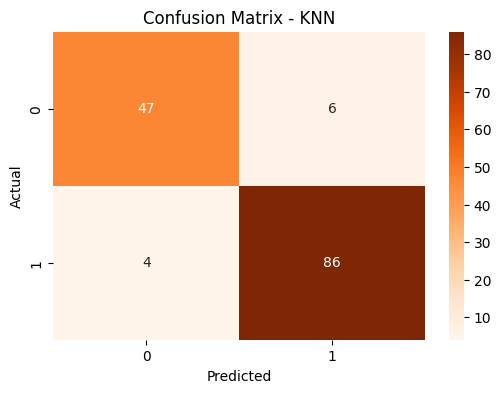

In [8]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6,4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges')

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [9]:
print("KNN Classification Report:\n")
print(classification_report(y_test, y_pred_knn))

KNN Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.89      0.90        53
           1       0.93      0.96      0.95        90

    accuracy                           0.93       143
   macro avg       0.93      0.92      0.92       143
weighted avg       0.93      0.93      0.93       143



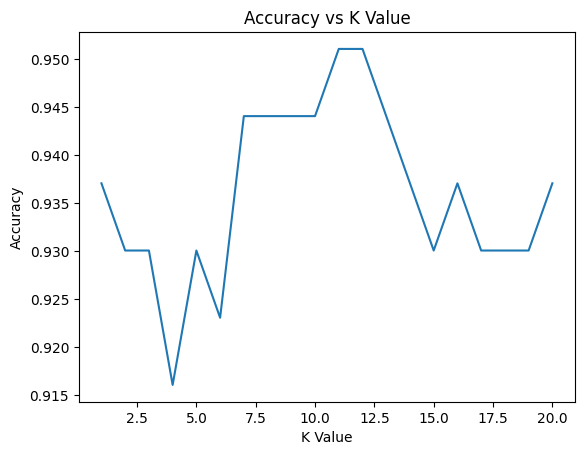

In [10]:
accuracy_values = []

for k in range(1,21):

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    accuracy_values.append(accuracy_score(y_test, pred))

plt.plot(range(1,21), accuracy_values)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K Value")

plt.show()

In [11]:
svm_model = SVC(kernel='linear', probability=True)

svm_model.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [12]:
y_pred_svm = svm_model.predict(X_test)

In [13]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.951048951048951


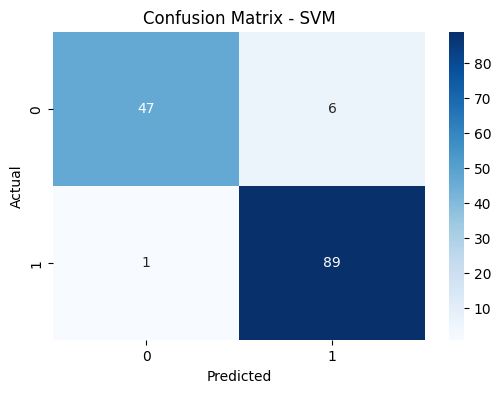

In [14]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [15]:
print("SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.89      0.93        53
           1       0.94      0.99      0.96        90

    accuracy                           0.95       143
   macro avg       0.96      0.94      0.95       143
weighted avg       0.95      0.95      0.95       143



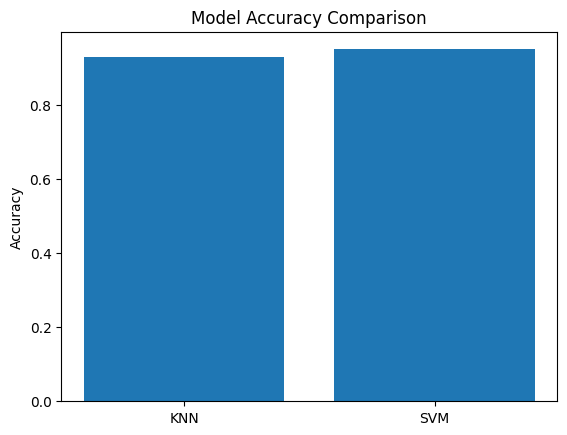

In [16]:
models = ['KNN', 'SVM']
accuracies = [knn_accuracy, svm_accuracy]

plt.bar(models, accuracies)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()

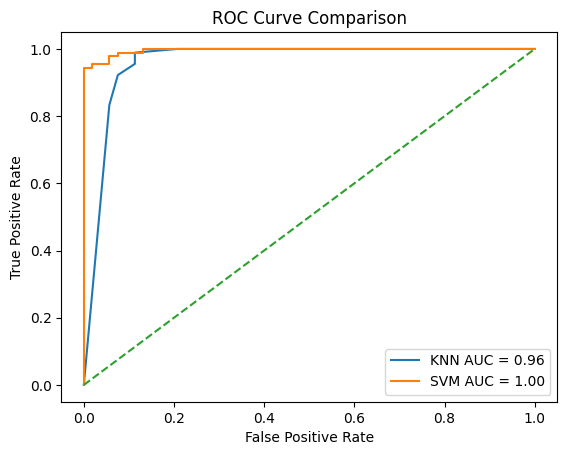

In [17]:
knn_prob = knn_model.predict_proba(X_test)[:,1]
svm_prob = svm_model.predict_proba(X_test)[:,1]

fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)

auc_knn = auc(fpr_knn, tpr_knn)
auc_svm = auc(fpr_svm, tpr_svm)

plt.plot(fpr_knn, tpr_knn, label="KNN AUC = %.2f" % auc_knn)
plt.plot(fpr_svm, tpr_svm, label="SVM AUC = %.2f" % auc_svm)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()


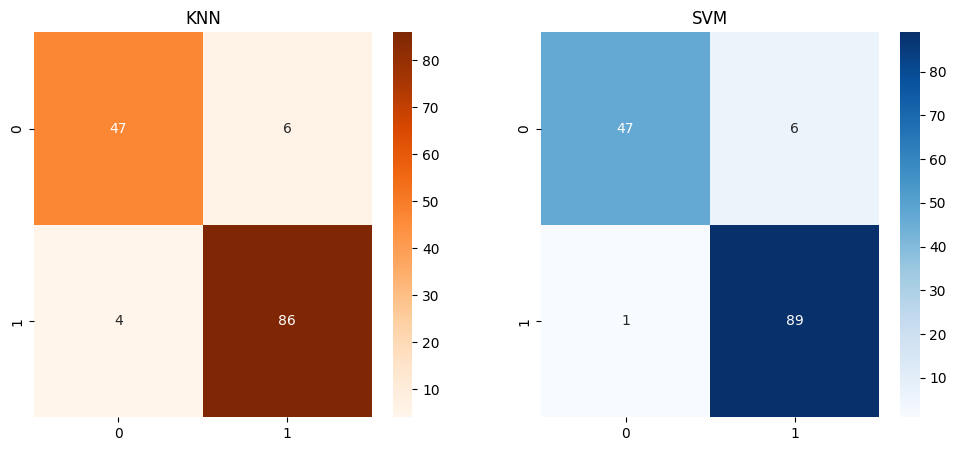

In [18]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', ax=ax[0])
ax[0].set_title("KNN")

sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title("SVM")

plt.show()